## Coffee Sales Performance Analysis

## Objective

To Analyze coffee sales data to identify top-selling products, customer buying patterns, payment preference,and sales trend over time-enabling, data-driven decisions for marketing inventory, and operations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Load Data Set

In [ ]:
coffee= pd.read_csv("Coffee.csv")

Read First and Buttom 5 rows

In [ ]:
coffee.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [ ]:
coffee.tail()

,date,datetime,cash_type,card,money,coffee_name
3631,2025-03-23,2025-03-23 10:34:54.894,card,ANON-0000-0000-1158,35.76,Cappuccino
3632,2025-03-23,2025-03-23 14:43:37.362,card,ANON-0000-0000-1315,35.76,Cocoa
3633,2025-03-23,2025-03-23 14:44:16.864,card,ANON-0000-0000-1315,35.76,Cocoa
3634,2025-03-23,2025-03-23 15:47:28.723,card,ANON-0000-0000-1316,25.96,Americano
3635,2025-03-23,2025-03-23 18:11:38.635,card,ANON-0000-0000-1275,35.76,Latte


Shape of Data (Columns & Rows)

In [ ]:
coffee.shape

(3636, 6)

In [ ]:
print(f"The Coffee Dataset have Total Number of Rows: {coffee.shape[0]} and \n Total Numbers of Columns {coffee.shape[1]}")

The Coffee Dataset have Total Number of Rows: 3636 and 
 Total Numbers of Columns 6


## Cleaning and Preparation

In [ ]:
#information of coffee dataset
coffee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


Check missing & duplicate

In [ ]:
#mising data
coffee.isnull().sum()

,0
date,0
datetime,0
cash_type,0
card,89
money,0
coffee_name,0


In [ ]:

#check percentage-wise
round((coffee.isnull().sum().sum())/(coffee.shape[0]*coffee.shape[1])*100,2)

np.float64(0.41)

In [ ]:
# handling missing
coffee["card"].fillna("Unknown", inplace= True)

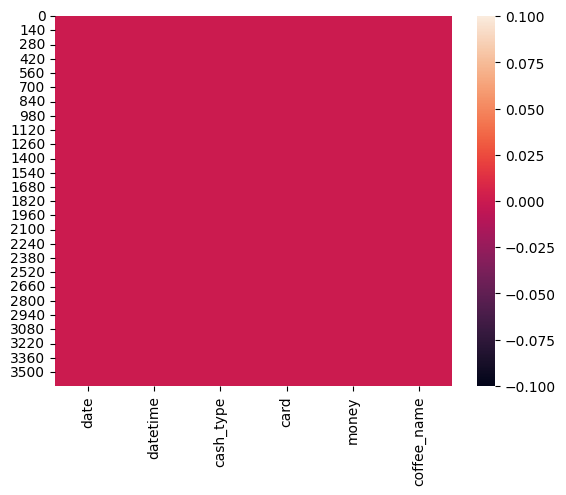

In [ ]:
sns.heatmap(coffee.isnull())
plt.show()

In [ ]:
#check duplicate
coffee.duplicated().sum()

np.int64(0)

Convert datetime & drop date columns

In [ ]:
coffee["datetime"] = pd.to_datetime(coffee["datetime"])

In [ ]:
coffee.drop("date", axis =1, inplace=True)

Check Column Type

In [ ]:
coffee.dtypes

,0
datetime,datetime64[ns]
cash_type,object
card,object
money,float64
coffee_name,object


Create Derived Column (Months , Weeks & hours)

In [ ]:
coffee["Month"] = coffee["datetime"].dt.month_name().str[:3]

In [ ]:
coffee["Week"] = coffee["datetime"].dt.day_name().str[:3]

In [ ]:
coffee["Hours"] = coffee["datetime"].dt.hour

# Exploraty Data Analysis & Visualization

In [ ]:
coffee.describe()

,datetime,money,Hours
count,3636,3636.000000,3636.000000
mean,2024-10-01 02:35:30.535053568,31.746859,14.166667
min,2024-03-01 10:15:50.520000,18.120000,6.000000
25%,2024-07-03 16:54:06.084750080,27.920000,10.000000
50%,2024-10-07 02:55:12.649500160,32.820000,14.000000
75%,2025-01-08 07:55:20.299750144,35.760000,18.000000
max,2025-03-23 18:11:38.635000,40.000000,22.000000
std,NaN,4.919926,4.227603


In [ ]:
coffee.describe(include="object")

,cash_type,card,coffee_name,Month,Week
count,3636,3636,3636,3636,3636
unique,2,1317,8,12,7
top,card,ANON-0000-0000-0012,Americano with Milk,Mar,Tue
freq,3547,129,824,525,585


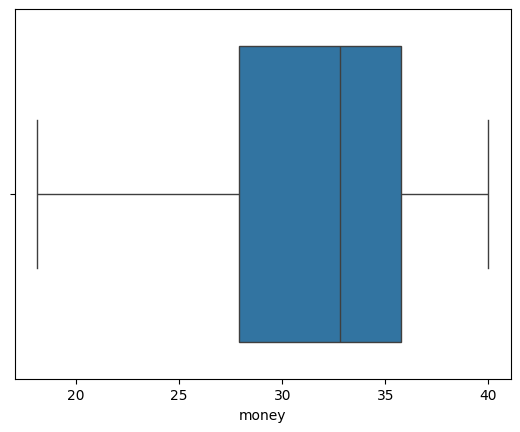

In [ ]:
#check Outlier
sns.boxplot(x ="money", data =coffee)
plt.show()

The ‘money’ column shows consistent values with no outliers detected.

## Q1: Top-Selling Coffee Products

In [ ]:
Top_selling_coffee = coffee.groupby("coffee_name")["money"].sum().reset_index()
Top_selling_coffee = Top_selling_coffee.sort_values(by = "money", ascending= False)
Top_selling_coffee

,coffee_name,money
7,Latte,27866.30
1,Americano with Milk,25269.12
2,Cappuccino,18034.14
0,Americano,15062.26
6,Hot Chocolate,10172.46
3,Cocoa,8678.16
4,Cortado,7534.86
5,Espresso,2814.28


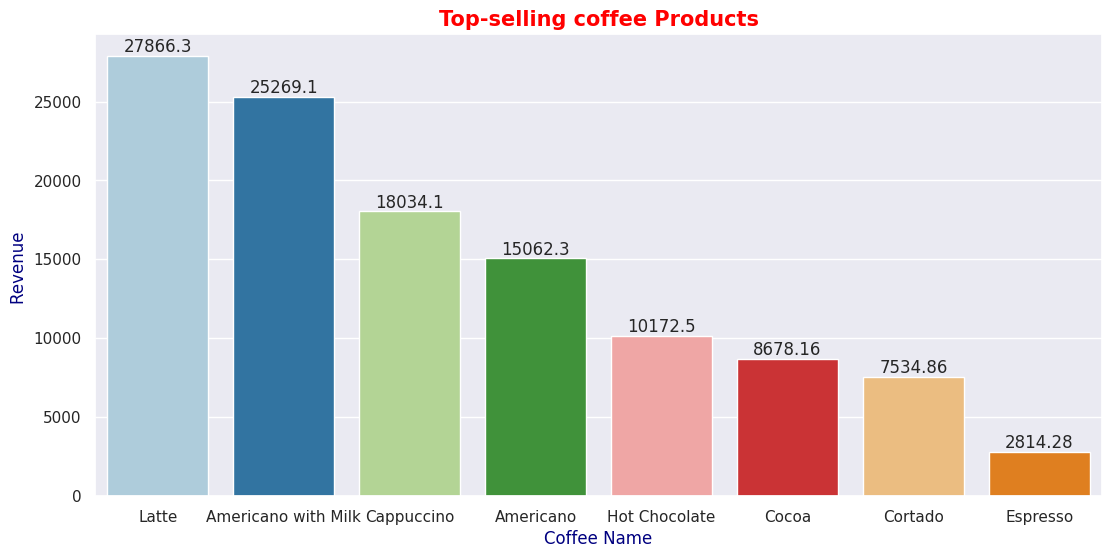

In [ ]:
plt.figure(figsize=(13,6))
sns.set_theme(style = "darkgrid")
ax = sns.barplot(x = "coffee_name", y = "money",
data = Top_selling_coffee, palette= "Paired")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Top-selling coffee Products",
size =15, color="red", fontweight= "bold")
plt.xlabel("Coffee Name", size = 12, color = "Navy")
plt.ylabel("Revenue ", size = 12, color= "navy")
plt.show()

Latte (24.1%) and Americano with Milk (21.9%) together contribute nearly 46% of total coffee sales revenue.

## Q2: Revenue Trends Over Time

In [ ]:
Monthly_Revenue= coffee.groupby("Month")["money"].sum().reset_index()
Monthly_Revenue = Monthly_Revenue.sort_values(by = "money", ascending= False)
Monthly_Revenue

,Month,money
7,Mar,17036.64
10,Oct,13891.16
3,Feb,13215.48
11,Sep,9988.64
8,May,9063.42
9,Nov,8590.54
2,Dec,8237.74
6,Jun,7758.76
1,Aug,7613.84
5,Jul,6915.94


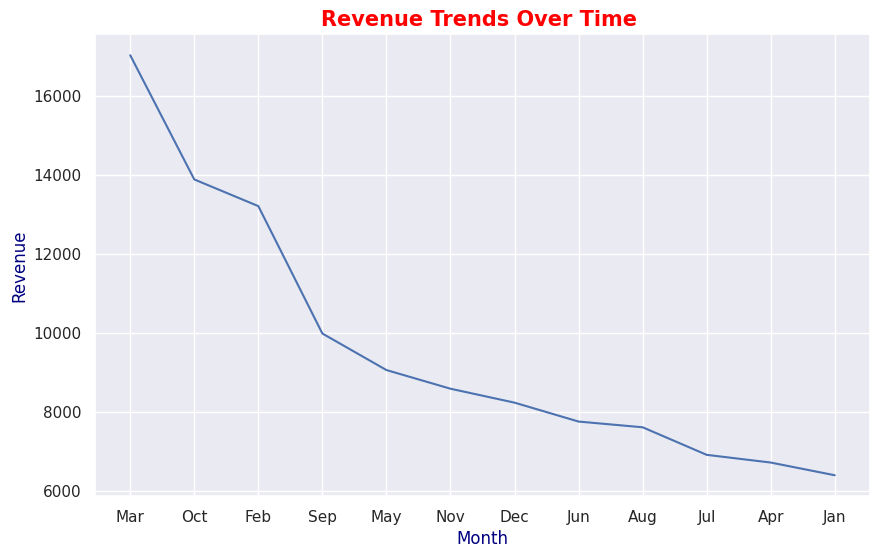

In [ ]:
plt.figure(figsize= (10,6))
sns.set_theme(style= "darkgrid")
sns.lineplot(x = "Month", y = "money",
data = Monthly_Revenue)
plt.title("Revenue Trends Over Time ", size=15,
color= "red", fontweight= "bold")
plt.xlabel("Month", size=12, color="navy")
plt.ylabel("Revenue", size=12, color="navy")
plt.show()

Revenue increased by 166% from January to March, with March recording the highest sales and January the lowest.

## Q3: Customer Buying Frequency

In [ ]:
Frequency_Customer = coffee["card"].value_counts().reset_index()[:5]
Frequency_Customer

,card,count
0,ANON-0000-0000-0012,129
1,ANON-0000-0000-0141,108
2,Unknown,89
3,ANON-0000-0000-1163,77
4,ANON-0000-0000-0276,69


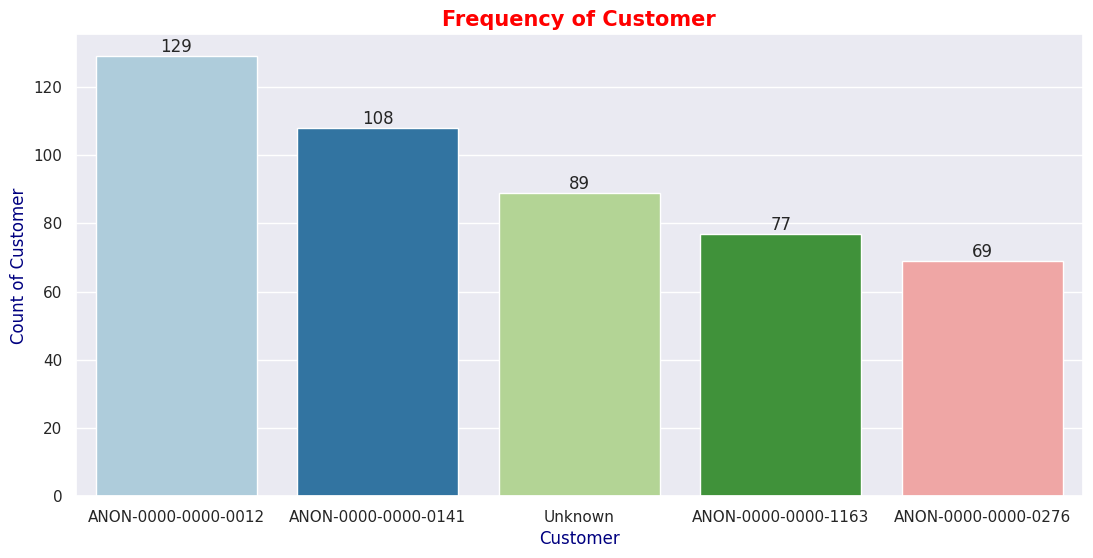

In [ ]:
plt.figure(figsize=(13,6))
sns.set_theme(style= "darkgrid")
ax = sns.barplot(x = "card", y = "count",
data = Frequency_Customer, palette ="Paired")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Frequency of Customer", size =15,
color= "red", fontweight="bold")
plt.xlabel("Customer", size =12,
color="navy")
plt.ylabel("Count of Customer", size=12,
color="navy")
plt.show()

Customer ANON-0000-0000-0012 made the highest number of purchases (129), followed by ANON-0000-0000-0141 (108). Unknown customers contributed 89 transactions, indicating a moderate share of unregistered buyers.

## Q4: Cash vs Card Transactions

In [ ]:
Transactions= coffee["cash_type"].value_counts().reset_index()
x = Transactions["cash_type"]
y = Transactions["count"]

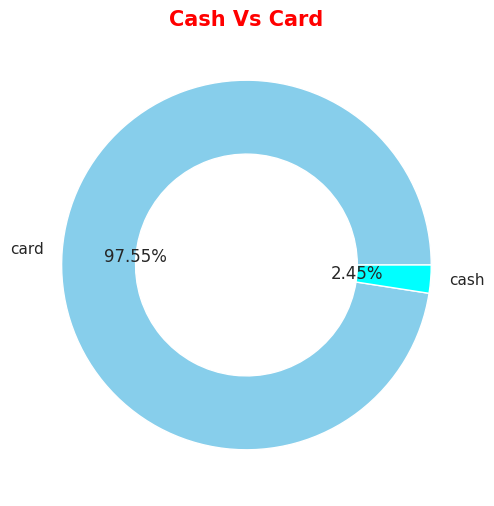

In [ ]:
plt.figure(figsize=(10,6))
plt.pie(y, labels=x, autopct="%0.2f%%",
wedgeprops={"width":0.4}, colors =["skyblue", "aqua"])
plt.title("Cash Vs Card", size =15,
color="red", fontweight="bold")
plt.show()

97.55% of customers used card payments for their transactions.

## Q5: Peak Hours or weeks for Coffee Sales

In [ ]:
hourly_sales= coffee.groupby("Hours")["money"].sum().reset_index()
hourly_sales = hourly_sales.sort_values(by ="money", ascending=False)
hourly_sales

,Hours,money
4,10,10994.52
10,16,9221.60
5,11,8849.10
13,19,7966.96
11,17,7925.00
9,15,7789.02
6,12,7668.62
3,9,7429.28
8,14,7265.80
12,18,7235.60


In [ ]:
Weekly_sales = coffee.groupby("Week")["money"].sum().reset_index()
Weekly_sales = Weekly_sales.sort_values(by ="money", ascending=False)
Weekly_sales

,Week,money
5,Tue,18637.38
1,Mon,17925.10
0,Fri,17257.66
4,Thu,16477.40
6,Wed,16093.46
2,Sat,15182.52
3,Sun,13858.06


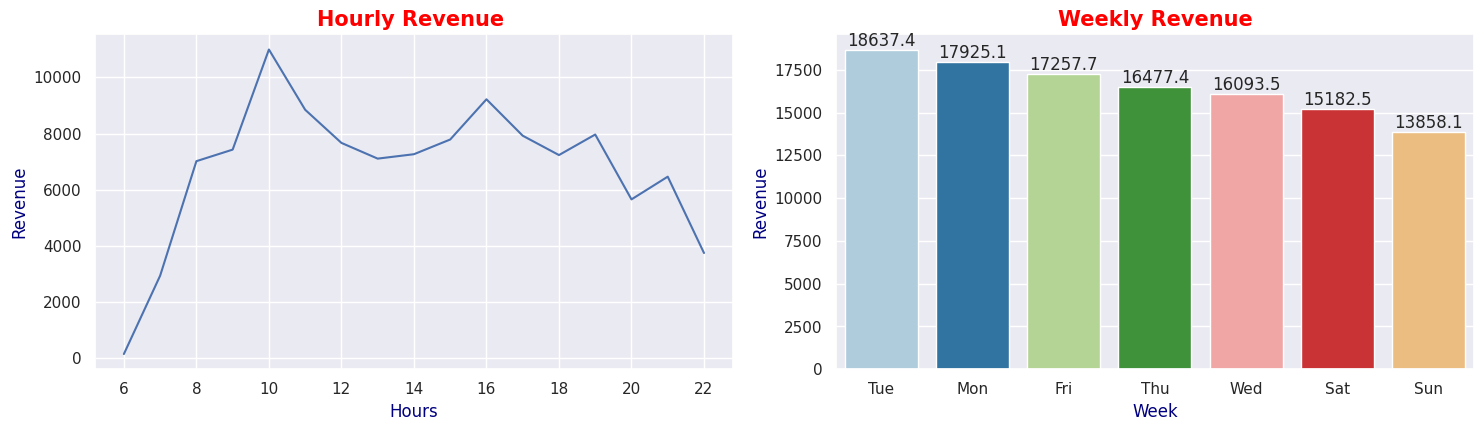

In [ ]:
plt.figure(figsize=(15,8))

#Hourly Revenue
plt.subplot(2,2,1)
sns.lineplot(x = "Hours", y = "money",
data = hourly_sales)
plt.title("Hourly Revenue ", size =15,
color="red", fontweight="bold")
plt.xlabel("Hours", size=12,
color="navy")
plt.ylabel("Revenue", size=12,
color="navy")
#Weekly Revenue
plt.subplot(2,2,2)
ax = sns.barplot(x = "Week", y ="money",
data = Weekly_sales, palette="Paired")
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Weekly Revenue", size=15,
color="Red", fontweight="bold")
plt.xlabel("Week", size =12,
color="navy")
plt.ylabel("Revenue", size=12,
color ="navy")
plt.tight_layout()
plt.show()

Peak coffee sales occur at 10 AM and on Tuesdays, whereas the lowest sales happen at 6 AM and Sundays — highlighting strong weekday and morning demand patterns.

## Consultation

Latte and Americano with Milk are the top-selling products, generating the highest revenue.
Revenue increased by 166%, showing strong growth.
Around 97.55% of customers prefer card payments, reflecting a shift toward digital transactions.
Peak sales occur between 8–10 AM and on Tuesdays, suggesting the cafe should focus staff and marketing efforts during these periods.